In [2]:
import pandas as pd

stock = pd.read_csv("../data/raw/AAPL.csv")

stock.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
stock["Date"] = pd.to_datetime(stock["Date"])
stock = stock.sort_values("Date")
stock = stock.dropna()
stock.set_index("Date", inplace=True)

stock.head()

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


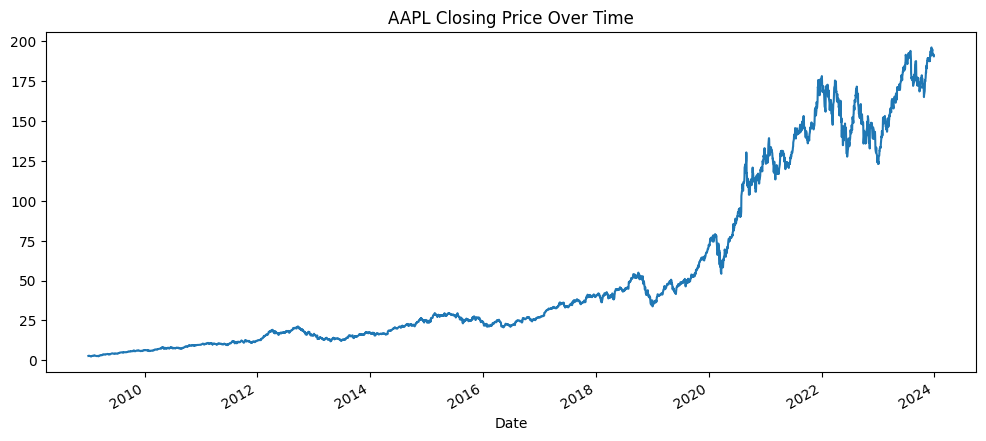

In [4]:
import matplotlib.pyplot as plt

stock["Close"].plot(figsize=(12,5))
plt.title("AAPL Closing Price Over Time")
plt.show()

In [5]:
stock["SMA_20"] = stock["Close"].rolling(window=20).mean()

In [6]:
stock["EMA_20"] = stock["Close"].ewm(span=20, adjust=False).mean()

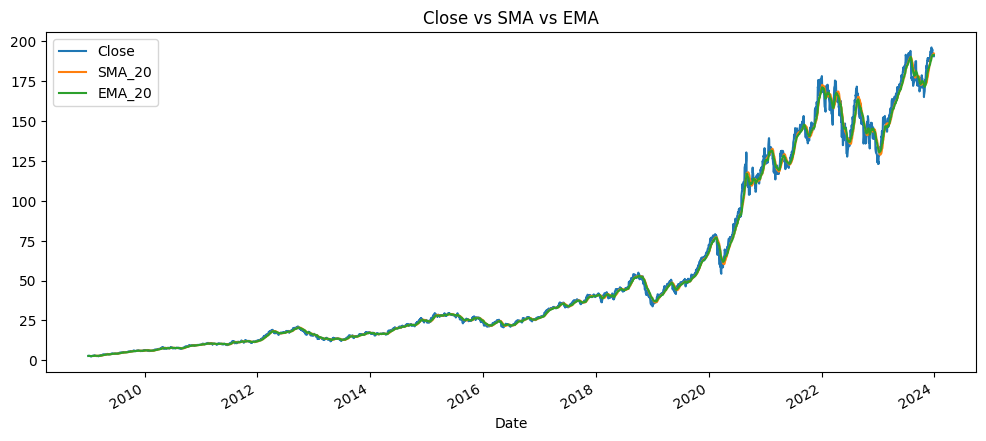

In [7]:
stock[["Close", "SMA_20", "EMA_20"]].plot(figsize=(12,5))
plt.title("Close vs SMA vs EMA")
plt.show()

In [8]:
pip install ta

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29497 sha256=10ecdf55a6437c0dea856d0ae85a3e92a00d2b5561f7d8721edb48320dee01cd
  Stored in directory: c:\users\user 1\appdata\local\pip\cache\wheels\a1\d7\29\7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from ta.momentum import RSIIndicator

stock["RSI"] = RSIIndicator(stock["Close"], window=14).rsi()

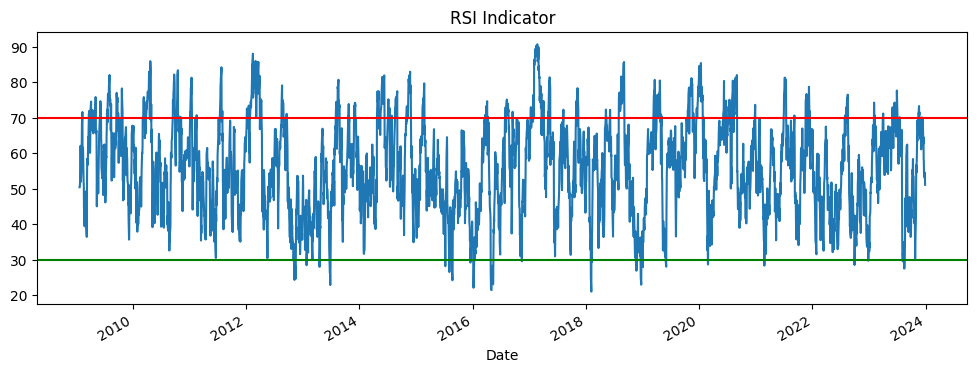

In [10]:
stock["RSI"].plot(figsize=(12,4))
plt.axhline(70, color="red")
plt.axhline(30, color="green")
plt.title("RSI Indicator")
plt.show()

In [12]:
from ta.trend import MACD

macd = MACD(stock["Close"])

stock["MACD"] = macd.macd()
stock["MACD_signal"] = macd.macd_signal()
stock["MACD_hist"] = macd.macd_diff()

In [13]:
stock[["MACD", "MACD_signal"]].head()

,MACD,MACD_signal
Date,,
2009-01-02,NaN,NaN
2009-01-05,NaN,NaN
2009-01-06,NaN,NaN
2009-01-07,NaN,NaN
2009-01-08,NaN,NaN


In [16]:
stock = stock.dropna()

In [17]:
stock[["MACD", "MACD_signal"]].head()

,MACD,MACD_signal
Date,,
2009-02-20,0.031682,0.059063
2009-02-23,0.011478,0.049546
2009-02-24,0.003413,0.040319
2009-02-25,-0.000768,0.032102
2009-02-26,-0.008748,0.023932


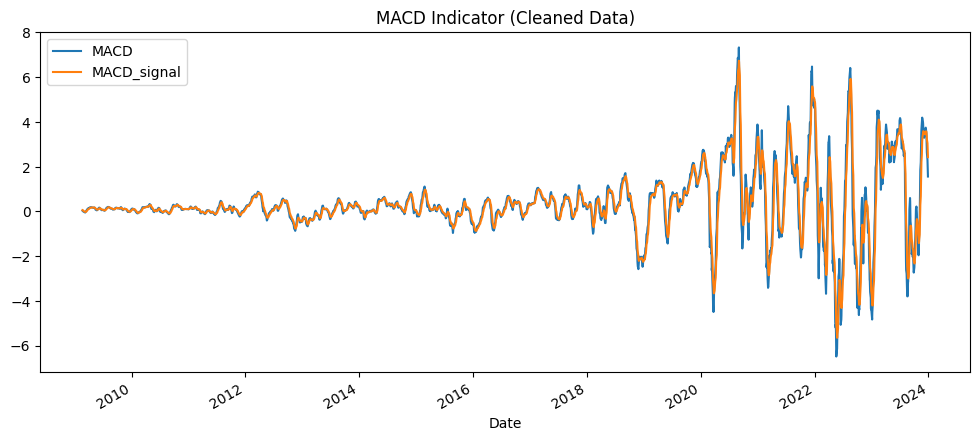

In [18]:
import matplotlib.pyplot as plt

stock[["MACD", "MACD_signal"]].plot(figsize=(12,5))
plt.title("MACD Indicator (Cleaned Data)")
plt.show()

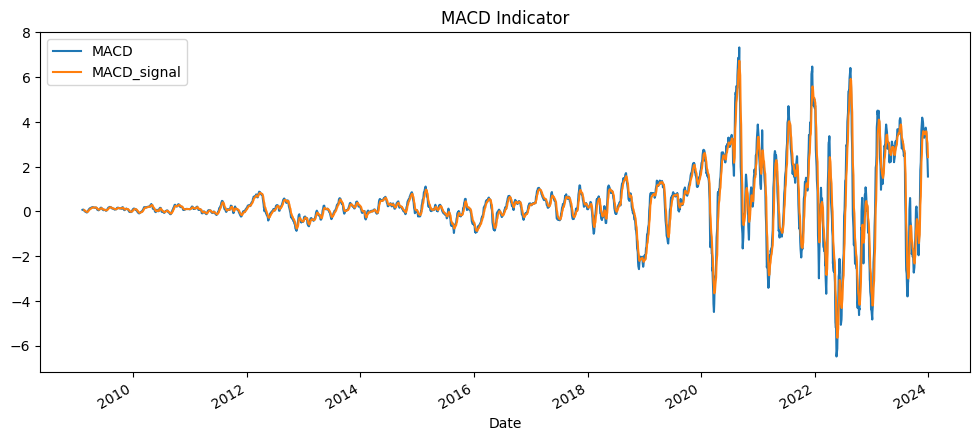

In [14]:
import matplotlib.pyplot as plt

stock[["MACD", "MACD_signal"]].plot(figsize=(12,5))
plt.title("MACD Indicator")
plt.show()

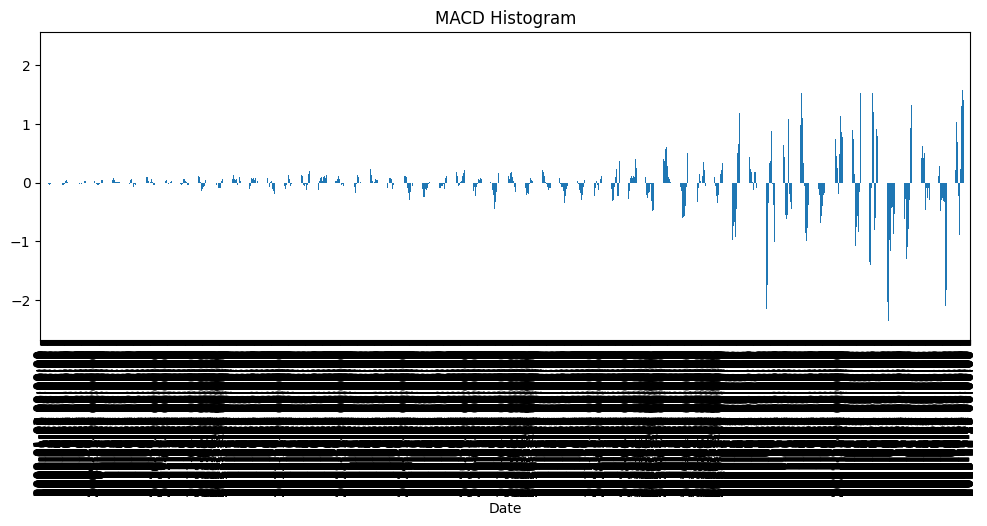

In [15]:
stock["MACD_hist"].plot(kind="bar", figsize=(12,4))
plt.title("MACD Histogram")
plt.show()